In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [73]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import warnings
warnings.filterwarnings('ignore')

In [53]:
# إعداد النموذج
model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)
model.load_state_dict(torch.load("D:\Education\كلية الهندسة جامعة حلوان\فرقة ثالثة - هندسة طبية\الترم الأول\Pattern Recognition\Project\Chest X-Ray Images (Pneumonia) Classification DL Model\pneumonia_model_-trained weights-.pth", map_location=torch.device('cpu')))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [55]:
# إعداد التحويلات
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [57]:
# Load test dataset
test_dir = "D:\Education\كلية الهندسة جامعة حلوان\فرقة ثالثة - هندسة طبية\الترم الأول\Pattern Recognition\Project\Chest X-Ray Images (Pneumonia) Classification DL Model\Test Dataset"
test_data = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [61]:
# Get class labels
class_names = test_data.classes  # ['Normal', 'Pneumonia']

In [65]:
# Initialize lists to store true and predicted labels
y_true = []
y_pred = []

In [67]:
# Perform evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())  # True labels
        y_pred.extend(predicted.cpu().numpy())  # Predicted labels

In [77]:
# Classification Report
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

              precision    recall  f1-score   support

      NORMAL       0.99      0.91      0.95       234
   PNEUMONIA       0.95      0.99      0.97       390

    accuracy                           0.96       624
   macro avg       0.97      0.95      0.96       624
weighted avg       0.96      0.96      0.96       624



In [69]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

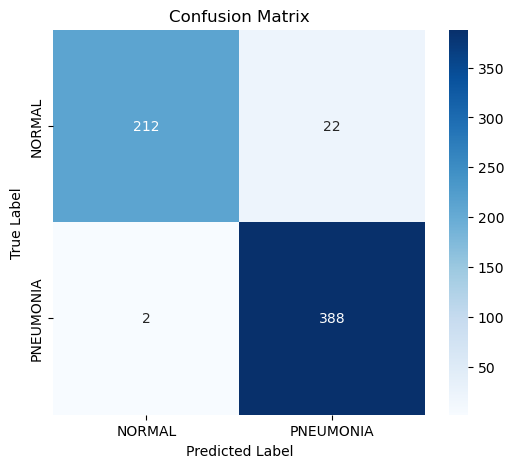

In [71]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()